# Notebook 3: Customer Segmentation with K-Means Clustering

This notebook segments the 2,240 customers into distinct personas using K-Means clustering, an unsupervised machine learning technique that finds natural groupings in the data based on multiple variables simultaneously.

**Approach:**
1. Select the behavioral and demographic features most relevant to segmentation
2. Standardize the features so each one has equal weight in the clustering
3. Use the Elbow Method to determine the optimal number of clusters
4. Apply K-Means with the chosen K and assign each customer to a cluster
5. Profile each cluster and assign descriptive persona names
6. Export the labeled dataset for use in the Tableau dashboard

**Why segmentation matters:**
Earlier analysis sliced customers one variable at a time (children/no children, education, channel preference). Segmentation considers all relevant variables simultaneously, surfacing natural personas the marketing team can target with tailored campaigns rather than treating all 2,240 customers identically.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the cleaned dataset from Notebook 1
df = pd.read_csv('marketing_campaign_clean.csv')

# Quick sanity check
print("Dataset loaded:", df.shape)
print("Columns:", len(df.columns))
print("Any missing values?", df.isnull().sum().sum())

Dataset loaded: (2240, 36)
Columns: 36
Any missing values? 0


## 1. Feature Selection

Selecting features for clustering follows three principles:

1. **Drop constant features** `Z_CostContact`, `Z_Revenue` have the same value for every customer.
2. **Drop ID columns** `ID` is a label, not a behavioral signal.
3. **Drop outcome features** `AcceptedCmp1-5`, `Response` describe how customers reacted to past marketing. We exclude these from clustering to avoid circular logic, then use them later to *profile* the clusters.

**Selected features (15):**
- **Demographics:** Income, Age, Children, Customer_Tenure_Days
- **Spending:** MntWines, MntMeatProducts, MntFishProducts, MntFruits, MntSweetProducts, MntGoldProds
- **Channels:** NumWebPurchases, NumCatalogPurchases, NumStorePurchases, NumDealsPurchases, NumWebVisitsMonth

In [2]:
# Define the features we'll use for clustering
clustering_features = [
    # Demographics
    'Income', 'Age', 'Children', 'Customer_Tenure_Days',
    # Spending across product categories
    'MntWines', 'MntMeatProducts', 'MntFishProducts',
    'MntFruits', 'MntSweetProducts', 'MntGoldProds',
    # Channel behavior
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumDealsPurchases', 'NumWebVisitsMonth'
]

# Create a clean working dataframe with just these features
X = df[clustering_features].copy()

# Quick check: do we have any extreme outliers in Age or Income that could distort clustering?
print("Feature summary statistics:\n")
print(X[['Income', 'Age']].describe().round(1))

Feature summary statistics:

         Income     Age
count    2240.0  2240.0
mean    52242.6    45.2
std     25039.1    12.0
min      1730.0    18.0
25%     35538.8    37.0
50%     51498.5    44.0
75%     68289.8    55.0
max    666666.0   121.0


## 2. Outlier Detection & Treatment

Initial summary statistics revealed two red flags:
- Maximum Age = 121 (looks like a data entry error)
- Maximum Income = $666,666 (likely extreme outlier)

These extreme values would distort K-Means clustering, which uses centroid means.
Let's identify them and decide whether to remove or cap them.

In [3]:
# Find unrealistic ages (anyone over 90 is suspect for a 2014 dataset)
print("Customers with Age > 90:")
print(df[df['Age'] > 90][['ID', 'Year_Birth', 'Age', 'Income', 'Total_Spent']])

print("\n" + "="*60 + "\n")

# Find extreme income outliers (anyone with income > $200K is far outside normal)
print("Customers with Income > $200,000:")
print(df[df['Income'] > 200000][['ID', 'Year_Birth', 'Age', 'Income', 'Total_Spent']])

Customers with Age > 90:
        ID  Year_Birth  Age   Income  Total_Spent
192   7829        1900  114  36640.0           65
239  11004        1893  121  60182.0           22
339   1150        1899  115  83532.0         1853


Customers with Income > $200,000:
        ID  Year_Birth  Age    Income  Total_Spent
2233  9432        1977   37  666666.0           62


### Outlier Treatment Decision

Found 4 customers with implausible values:
- 3 customers with Year_Birth in the 1890s/1900s (possible data entry where someone tried to enter 1980 or 1990)
- 1 customer with Income = $666,666 at age 37 but only $62 in spending (likely data entry error)

We will remove these 4 outliers before clustering.
This preserves the integrity of cluster centroids without meaningfully reducing sample size.

In [4]:
# Drop customers with impossible ages or extreme income
rows_before = len(df)

df = df[df['Age'] <= 90].copy()
df = df[df['Income'] <= 200000].copy()

rows_after = len(df)

print(f"Rows removed: {rows_before - rows_after}")
print(f"Final dataset: {rows_after} customers")

# Recreate the feature matrix X with the cleaned df
X = df[clustering_features].copy()

# Confirm the extreme values are gone
print("\nFeature ranges after outlier removal:")
print(X[['Income', 'Age']].describe().round(1))

Rows removed: 4
Final dataset: 2236 customers

Feature ranges after outlier removal:
         Income     Age
count    2236.0  2236.0
mean    51957.2    45.1
std     21412.8    11.7
min      1730.0    18.0
25%     35502.5    37.0
50%     51445.5    44.0
75%     68275.8    55.0
max    162397.0    74.0


## 3. Feature Scaling

K-Means measures distance between customers using raw values. Without scaling, features with large numeric ranges (like Income) would dominate the math, and features with small ranges (like Childrren) would be effectively ignored.

We use **StandardScaler** to transform every feature to:
- Mean = 0
- Standard deviation = 1



In [5]:
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the feature matrix
X_scaled = scaler.fit_transform(X)

# Convert back to a dataframe so we can inspect it
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features)

# Confirm scaling worked: every column should now have mean ~0 and std ~1
print("Mean of each scaled feature (should be ~0):")
print(X_scaled_df.mean().round(3))

print("\nStandard deviation of each scaled feature (should be ~1):")
print(X_scaled_df.std().round(3))

Mean of each scaled feature (should be ~0):
Income                 -0.0
Age                     0.0
Children                0.0
Customer_Tenure_Days    0.0
MntWines               -0.0
MntMeatProducts        -0.0
MntFishProducts         0.0
MntFruits              -0.0
MntSweetProducts        0.0
MntGoldProds            0.0
NumWebPurchases         0.0
NumCatalogPurchases    -0.0
NumStorePurchases      -0.0
NumDealsPurchases       0.0
NumWebVisitsMonth      -0.0
dtype: float64

Standard deviation of each scaled feature (should be ~1):
Income                  1.0
Age                     1.0
Children                1.0
Customer_Tenure_Days    1.0
MntWines                1.0
MntMeatProducts         1.0
MntFishProducts         1.0
MntFruits               1.0
MntSweetProducts        1.0
MntGoldProds            1.0
NumWebPurchases         1.0
NumCatalogPurchases     1.0
NumStorePurchases       1.0
NumDealsPurchases       1.0
NumWebVisitsMonth       1.0
dtype: float64


## 4. Choosing K: The Elbow Method

K-Means requires us to specify the number of clusters in advance. The Elbow Method helps choose K objectively.

**The idea:** As K increases, cluster tightness always improves. But at some point, adding more clusters yields diminishing returns. The *elbow* of the curve is the optimal K.

**The metric:** *Inertia* (within-cluster sum of squares)  total squared distance from each customer to their cluster centroid. Lower = tighter clusters.

We'll fit K-Means for K = 2 through 10 and plot inertia vs K to find the elbow.

K = 2: inertia = 22684
K = 3: inertia = 19764
K = 4: inertia = 18695
K = 5: inertia = 17727
K = 6: inertia = 16827
K = 7: inertia = 16192
K = 8: inertia = 15686
K = 9: inertia = 15199
K = 10: inertia = 14851


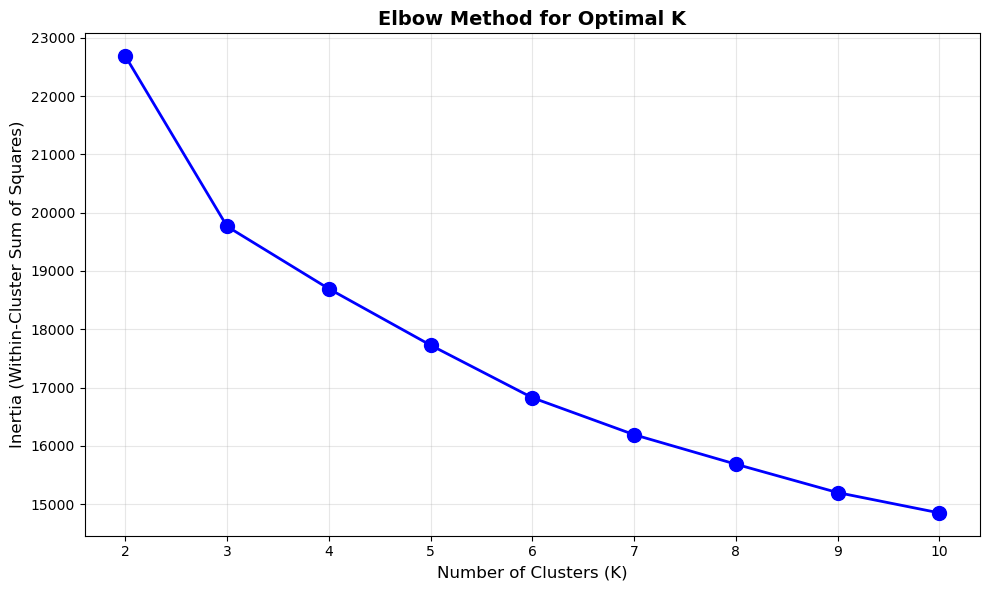

In [6]:
# Compute inertia for K = 2 through 10
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"K = {k}: inertia = {kmeans.inertia_:.0f}")

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Apply K-Means with K=4

Fitting K-Means with K=4 on the standardized features and assigning each customer a cluster label.
The label is added back to the original (unscaled) dataframe so cluster profiling uses real-world values like dollar amounts and ages, not standardized z-scores.

In [7]:
# Fit K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add the cluster labels as a new column on the original dataframe
df['Cluster'] = cluster_labels

# Confirm the assignment and check cluster sizes
print("Cluster size distribution:\n")
print(df['Cluster'].value_counts().sort_index())

print("\nPercentage of customers in each cluster:\n")
print((df['Cluster'].value_counts(normalize=True) * 100).sort_index().round(1))

Cluster size distribution:

Cluster
0    300
1    480
2    975
3    481
Name: count, dtype: int64

Percentage of customers in each cluster:

Cluster
0    13.4
1    21.5
2    43.6
3    21.5
Name: proportion, dtype: float64


## 6. Cluster Profiling

Now we examine the average behavior of each cluster on the variables that matter, demographics, spending, channel preference, and (critically) campaign response.

We deliberately include `Total_Campaigns_Accepted` and `Response` here even though we excluded them from clustering. This lets us see whether each cluster has a different campaign responsiveness.

In [8]:
# Profile each cluster on the dimensions that matter for marketing
cluster_profile = df.groupby('Cluster').agg(
    num_customers           = ('ID', 'count'),
    avg_income              = ('Income', 'mean'),
    avg_age                 = ('Age', 'mean'),
    avg_children            = ('Children', 'mean'),
    pct_with_children       = ('Has_Children', 'mean'),
    avg_total_spent         = ('Total_Spent', 'mean'),
    avg_wine                = ('MntWines', 'mean'),
    avg_meat                = ('MntMeatProducts', 'mean'),
    avg_web_purchases       = ('NumWebPurchases', 'mean'),
    avg_catalog_purchases   = ('NumCatalogPurchases', 'mean'),
    avg_store_purchases     = ('NumStorePurchases', 'mean'),
    avg_deals_purchases     = ('NumDealsPurchases', 'mean'),
    avg_web_visits_month    = ('NumWebVisitsMonth', 'mean'),
    avg_campaigns_accepted  = ('Total_Campaigns_Accepted', 'mean'),
    avg_campaign6_response  = ('Response', 'mean'),
    avg_tenure_days         = ('Customer_Tenure_Days', 'mean')
).round(1)

cluster_profile

,num_customers,avg_income,avg_age,avg_children,pct_with_children,avg_total_spent,avg_wine,avg_meat,avg_web_purchases,avg_catalog_purchases,avg_store_purchases,avg_deals_purchases,avg_web_visits_month,avg_campaigns_accepted,avg_campaign6_response,avg_tenure_days
Cluster,,,,,,,,,,,,,,,,
0,300,48524.5,47.3,1.6,1.0,472.3,292.6,89.8,5.8,2.0,5.7,5.6,7.2,0.4,0.2,467.6
1,480,63612.9,49.5,0.8,0.8,921.9,568.6,181.6,6.5,3.9,8.5,2.4,4.9,0.6,0.2,382.8
2,975,34922.3,42.4,1.2,0.9,88.8,37.6,20.6,2.0,0.5,3.2,1.8,6.3,0.2,0.1,306.3
3,481,76997.0,44.8,0.2,0.2,1422.5,587.6,497.3,4.9,6.2,8.4,1.3,2.5,0.9,0.3,350.1


## 7. Save the Labeled Dataset

Adding persona names as a new column and saving the final labeled dataset for use in the Tableau dashboard.

**Persona naming:**
- Cluster 0 → "Discount-Driven Families"
- Cluster 1 → "Engaged Mid-Spenders"
- Cluster 2 → "Disengaged Budget Customers"
- Cluster 3 → "Premium Loyalists"

In [9]:
# Map cluster numbers to descriptive persona names
persona_map = {
    0: 'Discount-Driven Families',
    1: 'Engaged Mid-Spenders',
    2: 'Disengaged Budget Customers',
    3: 'Premium Loyalists'
}

df['Persona'] = df['Cluster'].map(persona_map)

# Save the final labeled dataset
df.to_csv('marketing_campaign_labeled.csv', index=False)

# Confirm
print("Final labeled dataset saved as: marketing_campaign_labeled.csv")
print("Shape:", df.shape)
print("\nPersona distribution:")
print(df['Persona'].value_counts())
print("\nFirst 3 rows showing Cluster + Persona columns:")
df[['ID', 'Income', 'Total_Spent', 'Cluster', 'Persona']].head(3)

Final labeled dataset saved as: marketing_campaign_labeled.csv
Shape: (2236, 38)

Persona distribution:
Persona
Disengaged Budget Customers    975
Premium Loyalists              481
Engaged Mid-Spenders           480
Discount-Driven Families       300
Name: count, dtype: int64

First 3 rows showing Cluster + Persona columns:


,ID,Income,Total_Spent,Cluster,Persona
0,5524,58138.0,1617,3,Premium Loyalists
1,2174,46344.0,27,2,Disengaged Budget Customers
2,4141,71613.0,776,1,Engaged Mid-Spenders
